In [11]:
import os

base_dir = "/content/butterfly_classification"
subdirs = ["train", "val", "test"]
classes = ["papilio_demoleus", "danaus_chrysippus", "junonia_almana", "pieris_rapae", "graphium_agamemnon"]

for sub in subdirs:
    for cls in classes:
        path = os.path.join(base_dir, sub, cls)
        os.makedirs(path, exist_ok=True)

print("Đã tạo cấu trúc thư mục.")


Đã tạo cấu trúc thư mục.


In [12]:
import os
from torch.utils.data import Dataset
from PIL import Image

class ButterflyDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = sorted(os.listdir(root_dir))

        for label, class_name in enumerate(self.class_names):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.images.append(os.path.join(class_path, img_file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image = Image.open(image_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


In [13]:
from torchvision import transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_dataset = ButterflyDataset("/content/butterfly_classification/train", transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Kiểm tra thử
images, labels = next(iter(train_loader))
print(images.shape)  # Expected: [16, 3, 224, 224]
print(labels)        # Tensor chứa label từ 0–4


torch.Size([16, 3, 224, 224])
tensor([3, 0, 2, 2, 3, 3, 1, 4, 4, 4, 3, 3, 2, 4, 1, 1])


In [14]:
import timm
import torch.nn as nn

def build_model(model_name="resnet18", num_classes=5, pretrained=True):
    model = timm.create_model(model_name, pretrained=pretrained)

    # Xác định tên lớp cuối để sửa lại số output
    if hasattr(model, 'fc'):  # Ví dụ ResNet
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'classifier'):  # Ví dụ EfficientNet, MobileNet
        if isinstance(model.classifier, nn.Linear):
            in_features = model.classifier.in_features
            model.classifier = nn.Linear(in_features, num_classes)
        else:  # Một số mô hình dùng Sequential
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
    else:
        raise NotImplementedError("Không xác định được lớp cuối để sửa")

    return model


In [15]:
import torch

model = build_model(model_name="resnet18", num_classes=5)
print(model)  # Kiểm tra cấu trúc


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from dataset import ButterflyDataset
from model import build_model
import os

# Cấu hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 5
model_name = "resnet18"
batch_size = 16
epochs = 10
lr = 1e-4

# Tạo transform
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Tạo dataset
train_dataset = ButterflyDataset("/content/butterfly_classification/train", transform=train_transform)
val_dataset = ButterflyDataset("/content/butterfly_classification/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Khởi tạo mô hình
model = build_model(model_name, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Huấn luyện
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = 100. * correct / total

    # Đánh giá validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)
    val_acc = 100. * val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

# Lưu mô hình
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), f"models/{model_name}_butterfly.pth")


Epoch 1/10 | Train Acc: 28.67% | Val Acc: 46.46%
Epoch 2/10 | Train Acc: 56.33% | Val Acc: 68.69%
Epoch 3/10 | Train Acc: 78.67% | Val Acc: 78.79%
Epoch 4/10 | Train Acc: 89.67% | Val Acc: 87.88%
Epoch 5/10 | Train Acc: 92.33% | Val Acc: 88.89%
Epoch 6/10 | Train Acc: 97.00% | Val Acc: 90.91%
Epoch 7/10 | Train Acc: 97.33% | Val Acc: 93.94%
Epoch 8/10 | Train Acc: 96.67% | Val Acc: 97.98%
Epoch 9/10 | Train Acc: 97.33% | Val Acc: 94.95%
Epoch 10/10 | Train Acc: 97.33% | Val Acc: 98.99%


In [17]:
%%writefile dataset.py
import os
from torch.utils.data import Dataset
from PIL import Image

class ButterflyDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = sorted(os.listdir(root_dir))

        for label, class_name in enumerate(self.class_names):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.images.append(os.path.join(class_path, img_file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image = Image.open(image_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


Overwriting dataset.py


In [18]:
%%writefile model.py
import timm
import torch.nn as nn

def build_model(model_name="resnet18", num_classes=5, pretrained=True):
    model = timm.create_model(model_name, pretrained=pretrained)

    if hasattr(model, 'fc'):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Linear):
            in_features = model.classifier.in_features
            model.classifier = nn.Linear(in_features, num_classes)
        else:
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
    else:
        raise NotImplementedError("Không nhận diện được lớp cuối của model")

    return model



Overwriting model.py


In [24]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
from dataset import ButterflyDataset
from model import build_model
import numpy as np

# Cấu hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "resnet18"
num_classes = 5

# Load model
model = build_model(model_name=model_name, num_classes=num_classes)
model.load_state_dict(torch.load(f"models/{model_name}_butterfly.pth", map_location=device))
model.to(device)
model.eval()

# Transform test
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Dataset & Loader
test_dataset = ButterflyDataset("/content/butterfly_classification/test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Đánh giá
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# In kết quả
print("🎯 Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.class_names))


🎯 Confusion Matrix:
[[20  0  0  0  0]
 [ 0 19  0  0  1]
 [ 0  0 20  0  0]
 [ 0  0  0 20  0]
 [ 0  0  0  0 20]]

📋 Classification Report:
                    precision    recall  f1-score   support

 danaus_chrysippus       1.00      1.00      1.00        20
graphium_agamemnon       1.00      0.95      0.97        20
    junonia_almana       1.00      1.00      1.00        20
  papilio_demoleus       1.00      1.00      1.00        20
      pieris_rapae       0.95      1.00      0.98        20

          accuracy                           0.99       100
         macro avg       0.99      0.99      0.99       100
      weighted avg       0.99      0.99      0.99       100



In [25]:
from google.colab import files
uploaded = files.upload()


Saving images.jpg to images (2).jpg


In [26]:
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
import torch

def predict_image(image_path, model, class_names):
    # Chuẩn bị ảnh
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Dự đoán
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        predicted_class = class_names[pred.item()]

    # Hiển thị kết quả
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"🦋 Dự đoán: {predicted_class}")
    plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129419 (\N{BUTTERFLY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


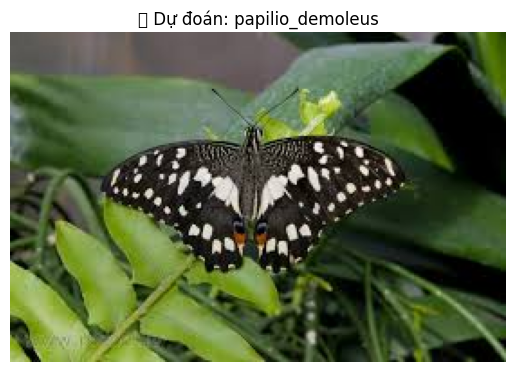

In [27]:
predict_image("images.jpg", model, test_dataset.class_names)


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
predict_image("Papilio demoleus demoleus_1678909017_247097.jpg", model, test_dataset.class_names)

In [ ]:
!pip install grad-cam


In [28]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import deprocess_image

import cv2
import numpy as np

def gradcam_visualize(image_path, model, target_layers, class_names):
    # Load ảnh và xử lý
    rgb_img = Image.open(image_path).convert('RGB').resize((224, 224))
    img_np = np.array(rgb_img) / 255.0
    img_tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])(rgb_img).unsqueeze(0).to(device)

    # Tính Grad-CAM
    cam = GradCAM(model=model, target_layers=target_layers, use_cuda=torch.cuda.is_available())
    targets = None  # hoặc: [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

    # Overlay heatmap
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # Hiển thị kết quả
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title("Ảnh gốc")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()


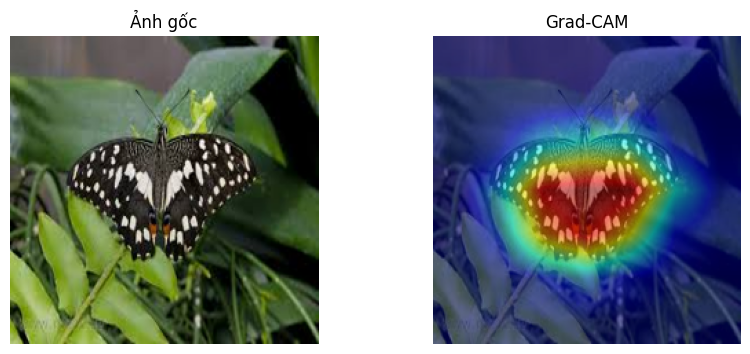

In [29]:
# Chọn layer cuối cùng của backbone model
# Ví dụ với resnet18: layer4
target_layers = [model.layer4[-1]]

gradcam_visualize("images.jpg", model, target_layers, test_dataset.class_names)


In [ ]:
!pip install grad-cam==1.4.8


In [30]:
from google.colab import files
uploaded = files.upload()


Saving Papilio demoleus demoleus_1678909017_247097.jpg to Papilio demoleus demoleus_1678909017_247097 (1).jpg


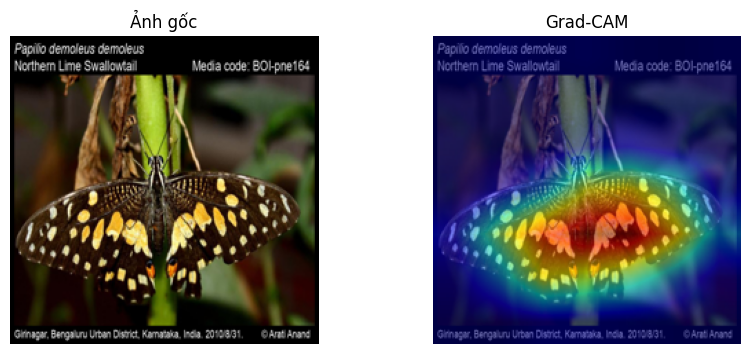

In [31]:
target_layers = [model.layer4[-1]]  # Nếu dùng resnet18
gradcam_visualize("Papilio demoleus demoleus_1678909017_247097.jpg", model, target_layers, test_dataset.class_names)


In [32]:
!pip install gradio --quiet


In [33]:
import gradio as gr
from PIL import Image

def predict_butterfly(image):
    image = image.convert("RGB").resize((224, 224))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)
        class_name = test_dataset.class_names[predicted.item()]

    return class_name


In [ ]:
interface = gr.Interface(
    fn=predict_butterfly,
    inputs=gr.Image(type="pil"),
    outputs="label",
    title="🦋 Nhận diện loài bướm",
    description="Tải ảnh cánh bướm để dự đoán tên loài"
)

interface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cff4a964c768a1fe8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [35]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

def predict_with_gradcam(image):
    # Chuẩn hóa ảnh
    image = image.convert("RGB").resize((224, 224))
    img_np = np.array(image) / 255.0
    img_tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])(image).unsqueeze(0).to(device)

    # Dự đoán
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
        class_name = test_dataset.class_names[predicted.item()]

    # Grad-CAM
    target_layers = [model.layer4[-1]]  # nếu là resnet18
    cam = GradCAM(model=model, target_layers=target_layers, use_cuda=torch.cuda.is_available())
    grayscale_cam = cam(input_tensor=img_tensor)[0]

    # Overlay heatmap
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    vis_pil = Image.fromarray(visualization)

    return vis_pil, class_name


In [36]:
import gradio as gr

interface = gr.Interface(
    fn=predict_with_gradcam,
    inputs=gr.Image(type="pil"),
    outputs=[gr.Image(type="pil", label="Grad-CAM Heatmap"), gr.Label(label="Loài bướm dự đoán")],
    title="🦋 Nhận diện loài bướm với Grad-CAM",
    description="Tải ảnh bướm để xem tên loài và vùng mô hình tập trung chú ý"
)

interface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://52b357b5504dba3159.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
